In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
y_score = lr.predict_proba(X_test)[:, 1]

In [9]:
y_score

array([0.2758698 , 0.18843781, 0.11448335, 0.16354256, 0.47152382,
       0.44181378, 0.01545858, 0.66077384, 0.54146156, 0.77732996,
       0.25591852, 0.89734396, 0.33619742, 0.3030328 , 0.08197907,
       0.38092474, 0.13935112, 0.0747936 , 0.8667417 , 0.5614278 ,
       0.2084072 , 0.07739223, 0.53963343, 0.09458139, 0.53950235,
       0.88554956, 0.12431156, 0.0301613 , 0.25152596, 0.11581091,
       0.91113266, 0.87075878, 0.76536338, 0.83753237, 0.6166828 ,
       0.68329681, 0.96813236, 0.24363452, 0.51147768, 0.73613319,
       0.0698326 , 0.59412031, 0.58366902, 0.32718608, 0.02758992,
       0.50239527, 0.63935312, 0.22533661, 0.36056019, 0.95629663,
       0.04889434, 0.6609671 , 0.81168271, 0.24552402, 0.09325442,
       0.04151937, 0.77816465, 0.00570348, 0.40861835, 0.75696035,
       0.74135346, 0.35193953, 0.19236342, 0.2049207 , 0.07687963,
       0.62716809, 0.05091408, 0.73285998, 0.03691782, 0.71593619,
       0.6752412 , 0.07016267, 0.18114703, 0.11429924, 0.09115

In [10]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_score)

In [11]:
thresholds

array([       inf, 0.9711561 , 0.96813236, 0.95629663, 0.90262603,
       0.89734396, 0.80096881, 0.77816465, 0.77790236, 0.77732996,
       0.73285998, 0.72427846, 0.68329681, 0.6752412 , 0.6609671 ,
       0.66077384, 0.6555797 , 0.64967438, 0.63935312, 0.6166828 ,
       0.60581093, 0.58366902, 0.55036131, 0.53950235, 0.53417645,
       0.50297285, 0.50239527, 0.42044451, 0.42016404, 0.40861835,
       0.38092474, 0.33903682, 0.32718608, 0.3030328 , 0.30267808,
       0.25731329, 0.24066432, 0.22533661, 0.22514667, 0.2084072 ,
       0.2049207 , 0.16354256, 0.14043021, 0.12822441, 0.12698244,
       0.11448335, 0.11429924, 0.04151937, 0.04047737, 0.00417261])

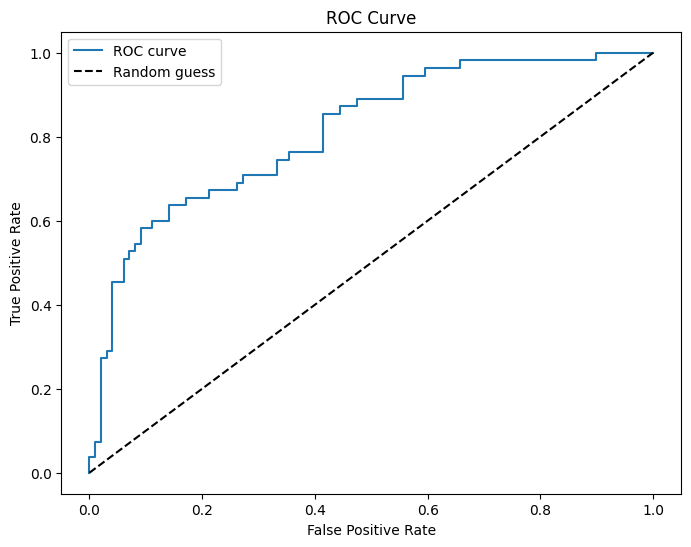

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [16]:
# using another library for a better plot
import plotly.graph_objects as go
import numpy as np


# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name='ROC curve'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)


# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=False
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


In [15]:
# Assume that fpr, tpr, thresholds have already been calculated
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)

Optimal threshold is: 0.5503613133055528
